# continuity

> Estimate and correct discontinuities between adjacent detectors.

In [ ]:
# | default_exp euclid.continuity

In [ ]:
# | exporti

import multiprocessing as mp
from functools import partial

import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
from numpy.linalg import lstsq
from regions import PolygonSkyRegion
from spherical_geometry.polygon import SphericalPolygon

from nicl.euclid.utilities import (
    get_dither_id_from_filename,
)
from nicl.utilities import does_image_overlap_with_skyregion, sigma_clip_stats

In [ ]:
# | hide
# additional imports for examples
%reload_ext autoreload
%autoreload now -p -l

from astropy.visualization import ImageNormalize, ZScaleInterval
from itertools import chain

from matplotlib import pyplot as plt
from nicl.euclid.constants import NISP
from nicl.euclid.utilities import assemble_fpa_mosaic, default_data_path
from nicl.utilities import compute_pixel_scales

plt.style.use("nicl.euclid.v1nicl")

In [ ]:
# | export


def get_overlap_chip(hdr, hdul, chip_layout, threshold=0.01):
    """Get the chip id (target dither) that overlaps with the chip pair in the current dither. Sparsely sampling image boundary for better speed."""
    sky_reg = SphericalPolygon.from_wcs(hdr)
    chips = []
    for chip in np.nditer(chip_layout):
        chip = str(chip)
        hdr = hdul[chip + ".SCI"].header
        is_overlapped = does_image_overlap_with_skyregion(
            hdr, sky_reg, threshold=threshold
        )
        if is_overlapped:
            chips.append(chip)
    return chips


def compute_offset_between_chips(hdu, target_hdus, steps=10):
    """Compute the offsets between the overlapping chips in the target dither and the given chip in the current dither."""
    # use SphericalPolygon to compute the accurate overlap region
    current_poly = SphericalPolygon.from_wcs(hdu.header, steps=steps)
    offsets = []
    for target_hdu in target_hdus:
        target_poly = SphericalPolygon.from_wcs(target_hdu.header, steps=steps)
        if not current_poly.intersects_poly(target_poly):
            raise ValueError(
                f"Chip {target_hdu.header['extname']} does not overlap with the current dither chip {hdu.header['extname']}."
            )
        overlap_poly = current_poly.intersection(target_poly)
        sb, sb_err = polygon_photometry(overlap_poly, hdu)
        target_sb, target_sb_err = polygon_photometry(overlap_poly, target_hdu)
        # compute the offset
        offset = sb - target_sb
        offset_err = np.sqrt(sb_err**2 + target_sb_err**2)
        offsets.append((offset, offset_err))
    return offsets


def polygon_photometry(skyreg, hdu):
    """Perform polygon photometry on the given data using the provided sky region and WCS.

    This function computes the mean value of the pixels within the polygon region.
    """
    img = hdu.data
    hdr = hdu.header
    sky_area = skyreg.area()
    # get magnitude zero point; MAGZEROP is for VIS, ZPAB is the default key for NISP
    if "QUAD_ID" in hdr:
        target_mag_zpt = 24.56605
        target_pix_scl = 0.1
        mag_zpt = hdr.get("MAGZEROP")
    else:
        target_mag_zpt = 30
        target_pix_scl = 0.3
        mag_zpt = hdr.get("ZPAB")
    if mag_zpt is None:
        raise ValueError(
            "Magnitude zero point not found in header (missing MAGZEROP and ZPAB keys)"
        )
    # construct a PolygonSkyRegion to do photometry
    ra, dec = list(skyreg.to_radec())[0]
    skyreg_ = PolygonSkyRegion(SkyCoord(ra[:-1], dec[:-1], unit="deg"))
    # Convert the sky region to pixel coordinates
    wcs = WCS(hdr)
    pixreg = skyreg_.to_pixel(wcs)
    # mode="exact" not implemented in regions yet for polygons
    # also we don't need accurate pixel footprint since we are taking the mean/median
    regmask = pixreg.to_mask(mode="center")
    nanmask = np.isnan(img)
    extracted_data = regmask.get_values(img, mask=nanmask)
    # print(extracted_data)
    robust_mean, _, _, robust_mean_err = sigma_clip_stats(
        extracted_data, sigma_upper=2.5, sigma_lower=3, ngood_min=3
    )
    # print(f"robust mean: {robust_mean}, robust mean error: {robust_mean_err}")
    if not np.isnan(robust_mean):
        pix_area = pixreg.area
        # convert sky area from steradians to square arcseconds
        sky_area = sky_area * (180 * 3600 / np.pi) ** 2
        sky_area_per_pix = sky_area / pix_area
        # sky_area_per_pix=wcs.proj_plane_pixel_area().to(u.arcsec**2).value
        # print(f"sky area per pixel: {sky_area_per_pix}")
        # generalize to the same zpt and pixel scale
        adjusted_intensity = (
            robust_mean
            / sky_area_per_pix
            * target_pix_scl**2
            * 10 ** (-0.4 * (mag_zpt - target_mag_zpt))
        )
        adjusted_intensity_error = (
            robust_mean_err
            / sky_area_per_pix
            * target_pix_scl**2
            * 10 ** (-0.4 * (mag_zpt - target_mag_zpt))
        )
        # adjusted_intensity = robust_mean / sky_area_per_pix * target_pix_scl**2
        # adjusted_intensity_error = robust_mean_err / sky_area_per_pix * target_pix_scl**2
        # adjusted_intensity = robust_mean
        # adjusted_intensity_error = robust_mean_err
        return adjusted_intensity, adjusted_intensity_error
    else:
        return np.nan, np.nan


def form_dither_pairs(dithers):
    """Form dither pairs from the list of dither files. It removes short exposures for now."""
    dithers.sort()
    dithers_ = []
    for dither in dithers:
        dither_id = get_dither_id_from_filename(dither)
        if len(dither_id) > 1 and dither_id.endswith("1"):
            continue
        dithers_.append(dither)
    # form unique dither pairs among four dithers
    dither_pairs = []
    for i in range(len(dithers_)):
        for j in range(i + 1, len(dithers_)):
            dither_pairs.append((dithers_[i], dithers_[j]))
    return dither_pairs


def _mask_in_place(hdu, mask):
    """Mask the data in place. So we don't need to pass around the dq hdu."""
    if mask is None:
        return
    if hdu.data is None:
        raise ValueError("Data is None")
    if mask.shape != hdu.data.shape:
        raise ValueError("Mask shape does not match data shape")
    # mask the data in place
    hdu.data[mask] = np.nan

In [ ]:
# | export


def measure_offset_per_dither_pair(dither_pair, instrument):
    dither1, dither2 = dither_pair
    chip_pairs = []
    offsets = []
    with fits.open(dither1) as hdul1, fits.open(dither2) as hdul2:
        # collect all headers from hdul2
        # target_hdrs = [hdul2[chip + ".SCI"].header for chip in np.nditer(instrument.chip_layout)]
        # loop over chips in hdul1
        for chip in np.nditer(instrument.chip_layout):
            chip = str(chip)
            hdr = hdul1[chip + ".SCI"].header
            target_chips = get_overlap_chip(hdr, hdul2, instrument.chip_layout)
            # measure the offset between the chips in dither1 and dither2
            # first mask out bad pixels
            if instrument.name == "VIS":
                dq_img = hdul1[chip + ".FLG"].data
                # additional bits: bright star, detected sources
                bits = list(instrument.bad_pix_bits) + [18, 24]
            elif instrument.name == "NISP":
                dq_img = hdul1[chip + ".DQ"].data
                # additional bits: scattered Light, moving Object, Transients; unfortunately no bit for detected sources
                bits = list(instrument.bad_pix_bits) + [19, 20, 21]
            mask = np.any(
                [(dq_img & 2**bit > 0) for bit in bits],
                axis=0,
            )
            _mask_in_place(hdul1[chip + ".SCI"], mask)
            for target_chip in target_chips:
                if instrument.name == "VIS":
                    dq_img = hdul2[target_chip + ".FLG"].data
                elif instrument.name == "NISP":
                    dq_img = hdul2[target_chip + ".DQ"].data
                mask = np.any(
                    [(dq_img & 2**bit > 0) for bit in bits],
                    axis=0,
                )
                _mask_in_place(hdul2[target_chip + ".SCI"], mask)
            hdus = [hdul2[chip + ".SCI"] for chip in target_chips]
            offset = compute_offset_between_chips(hdul1[chip + ".SCI"], hdus)
            chip_pairs.extend([(chip, target_chip) for target_chip in target_chips])
            offsets.extend(offset)
        dither_id1 = get_dither_id_from_filename(dither1)
        dither_id2 = get_dither_id_from_filename(dither2)
        res = {
            "instrument": instrument,
            "dither pair": (dither_id1, dither_id2),
            "chip pair": chip_pairs,
            "offset": offsets,
        }
        return res


# | export


def measure_offset_per_observation(dir, obsid, instrument, filter):
    """Measure the offset between the overlapping chips among the dithers of one observation.

    Uses multiprocessing to parallelize processing of dither pairs.
    """
    if filter not in instrument.filters:
        raise ValueError(f"Filter {filter} is not available for {instrument.name}.")
    if instrument.name == "VIS":
        filter = ""
    # find the dither files
    dithers = list(dir.glob(f"**/EUC_*{filter}*{obsid}-*.fits"))
    # form dither pairs
    dither_pairs = form_dither_pairs(dithers)

    if not dither_pairs:
        return []

    # Use multiprocessing to process dither pairs in parallel
    num_processes = min(mp.cpu_count(), len(dither_pairs))
    process_func = partial(measure_offset_per_dither_pair, instrument=instrument)
    with mp.Pool(processes=num_processes) as pool:
        results = pool.map(process_func, dither_pairs)

    # Post-process the results to add additional information
    offset_dicts = []
    for result in results:
        result["obsid"] = obsid
        result["filter"] = filter
        offset_dicts.append(result)

    return offset_dicts

In [ ]:
# | export


def solve_for_correction_per_observation(offset_dicts):
    instrument = offset_dicts[0]["instrument"]
    # Flatten the tuples of dither pairs before making the set
    unique_dithers = set(
        dither for offset_dict in offset_dicts for dither in offset_dict["dither pair"]
    )
    solutions_finder_chart = [
        dither + "." + str(chip)
        for dither in unique_dithers
        for chip in np.nditer(instrument.chip_layout)
    ]
    num_solutions = len(solutions_finder_chart)
    a = []
    b = []
    for offset_dict in offset_dicts:
        dither1, dither2 = offset_dict["dither pair"]
        for (chip1, chip2), (offset, offset_err) in zip(
            offset_dict["chip pair"], offset_dict["offset"]
        ):
            if np.isfinite(offset):
                coeff_array = np.zeros(num_solutions)
                idx1 = solutions_finder_chart.index(dither1 + "." + chip1)
                idx2 = solutions_finder_chart.index(dither2 + "." + chip2)
                coeff_array[idx1] = 1
                coeff_array[idx2] = -1
                a.append(coeff_array)
                b.append(-offset)
    a = np.array(a)
    b = np.array(b)
    print("number of equations: ", len(a))
    print("number of unknowns: ", num_solutions)
    solutions, residuals, rank, _ = lstsq(a, b, rcond=None)
    if rank < num_solutions or len(a) < num_solutions:
        residuals = np.linalg.norm(b - a @ solutions)
    print(f"rank: {rank}, residuals: {residuals}")
    # map solutions to the dither chips using the solutions_finder_chart
    mapped_solutions = {
        chart: solution for chart, solution in zip(solutions_finder_chart, solutions)
    }
    return mapped_solutions, residuals / np.sqrt(len(b))


def apply_correction(
    dir, obsid, instrument, filter, solutions, out_dir=None, overwrite=False
):
    if filter not in instrument.filters:
        raise ValueError(f"Filter {filter} is not available for {instrument.name}.")
    if instrument.name == "VIS":
        filter = ""
        target_mag_zpt = 24.56605
        target_pix_scl = 0.1
        zpt_key = "MAGZEROP"
    else:
        target_mag_zpt = 30
        target_pix_scl = 0.3
        zpt_key = "ZPAB"
    # find the dither files
    dithers = list(dir.glob(f"**/EUC_*{filter}*{obsid}-*.fits"))
    num_processes = min(mp.cpu_count(), len(dithers))
    process_func = partial(
        correct_dither,
        instrument=instrument,
        solutions=solutions,
        target_pix_scl=target_pix_scl,
        target_mag_zpt=target_mag_zpt,
        zpt_key=zpt_key,
        out_dir=out_dir,
        overwrite=overwrite,
    )
    with mp.Pool(processes=num_processes) as pool:
        pool.map(process_func, dithers)


def correct_dither(
    dither,
    instrument,
    solutions,
    target_pix_scl,
    target_mag_zpt,
    zpt_key,
    out_dir=None,
    overwrite=False,
):
    """Apply the discontinuity correction to a dither."""
    dither_id = get_dither_id_from_filename(dither)
    with fits.open(dither) as hdul:
        # loop over chips in hdul
        for chip in np.nditer(instrument.chip_layout):
            chip = str(chip)
            hdr = hdul[chip + ".SCI"].header
            mag_zpt = hdr.get(zpt_key)
            eff_pix_scl = compute_pixel_scales(hdr)
            corr = solutions[dither_id + "." + chip]
            corr_arr = (
                corr
                / target_pix_scl**2
                * eff_pix_scl**2
                * 10 ** (0.4 * (mag_zpt - target_mag_zpt))
            )
            hdul[chip + ".SCI"].data += corr_arr
            # update the header
            hdr.add_history(f"Applied discontinuity correction {corr} to {chip}.")
        if out_dir is None:
            out_dir = dither.parent
        out_fn = out_dir / (dither.stem + "_corr.fits")
        hdul.writeto(out_fn, overwrite=overwrite)

## Examples

## generate mock data for testing

Four mock NISP dithers with real WCS from `obsid=2683` and fake background at ~100 ADU. Perhaps inject fake sources as well.

In [ ]:
dithers_dir = default_data_path("Q1_R1", "NIR", "2683")
dither_paths = dithers_dir.glob("EUC_NIR_W-CAL-IMAGE_H-2683-*.fits")
mock_dithers_dir = default_data_path("Q1_R1_mock", "continuity", "sky")
sky_ped = 100.0
sky_rms = 5.0
chip_discon = 1.0
for path in dither_paths:
    dither_id = get_dither_id_from_filename(path)
    with fits.open(path) as hdul:
        hdul_ = [hdul[0]]
        for ext in NISP.extnames:
            hdr = hdul[ext + ".SCI"].header
            mag_zpt = hdr.get("ZPAB")
            nx, ny = hdr["NAXIS1"], hdr["NAXIS2"]
            pix_scl_eff = compute_pixel_scales(hdr)
            # shit the sky level by 1 adu every dither
            img = np.random.normal(sky_ped + int(dither_id), sky_rms, (ny, nx))
            # introduce some discontinuity as sb
            img += np.random.choice([-chip_discon, chip_discon])
            # acount for variations in pixel scale and magnitude zero point
            img *= (pix_scl_eff / 0.3) ** 2 * 10 ** (0.4 * (mag_zpt - 30))
            # introduce some discontinuity as raw counts
            # img += np.random.choice([-chip_discon, chip_discon])
            # create rms extension
            rms = np.full((ny, nx), sky_rms)
            rms *= (pix_scl_eff / 0.3) ** 2 * 10 ** (0.4 * (mag_zpt - 30))
            rms_hdr = hdul[ext + ".RMS"].header
            # create dq extension
            dq = np.zeros((ny, nx), dtype=np.uint8)
            dq_hdr = hdul[ext + ".DQ"].header
            hdul_.append(fits.ImageHDU(img, header=hdr))
            hdul_.append(fits.ImageHDU(rms, header=rms_hdr))
            hdul_.append(fits.ImageHDU(dq, header=dq_hdr))
        hdul_ = fits.HDUList(hdul_)
        out_path = (
            mock_dithers_dir / f"EUC_NIR_W-CAL-IMAGE_H-2683-{dither_id}_mock.fits"
        )
        out_path.parent.mkdir(parents=True, exist_ok=True)
        hdul_.writeto(out_path, overwrite=True)

## plot the mock dithers

In [ ]:
mock_dithers = mock_dithers_dir.glob("EUC_NIR_W-CAL-IMAGE_H-2683-*.fits")
fpas = {}
for path in mock_dithers:
    dither_id = get_dither_id_from_filename(path)
    with fits.open(path) as hdul:
        fpa = assemble_fpa_mosaic(hdul, instrument="NISP", binsize=10, unify_zpt=30)
        fpas[dither_id] = fpa

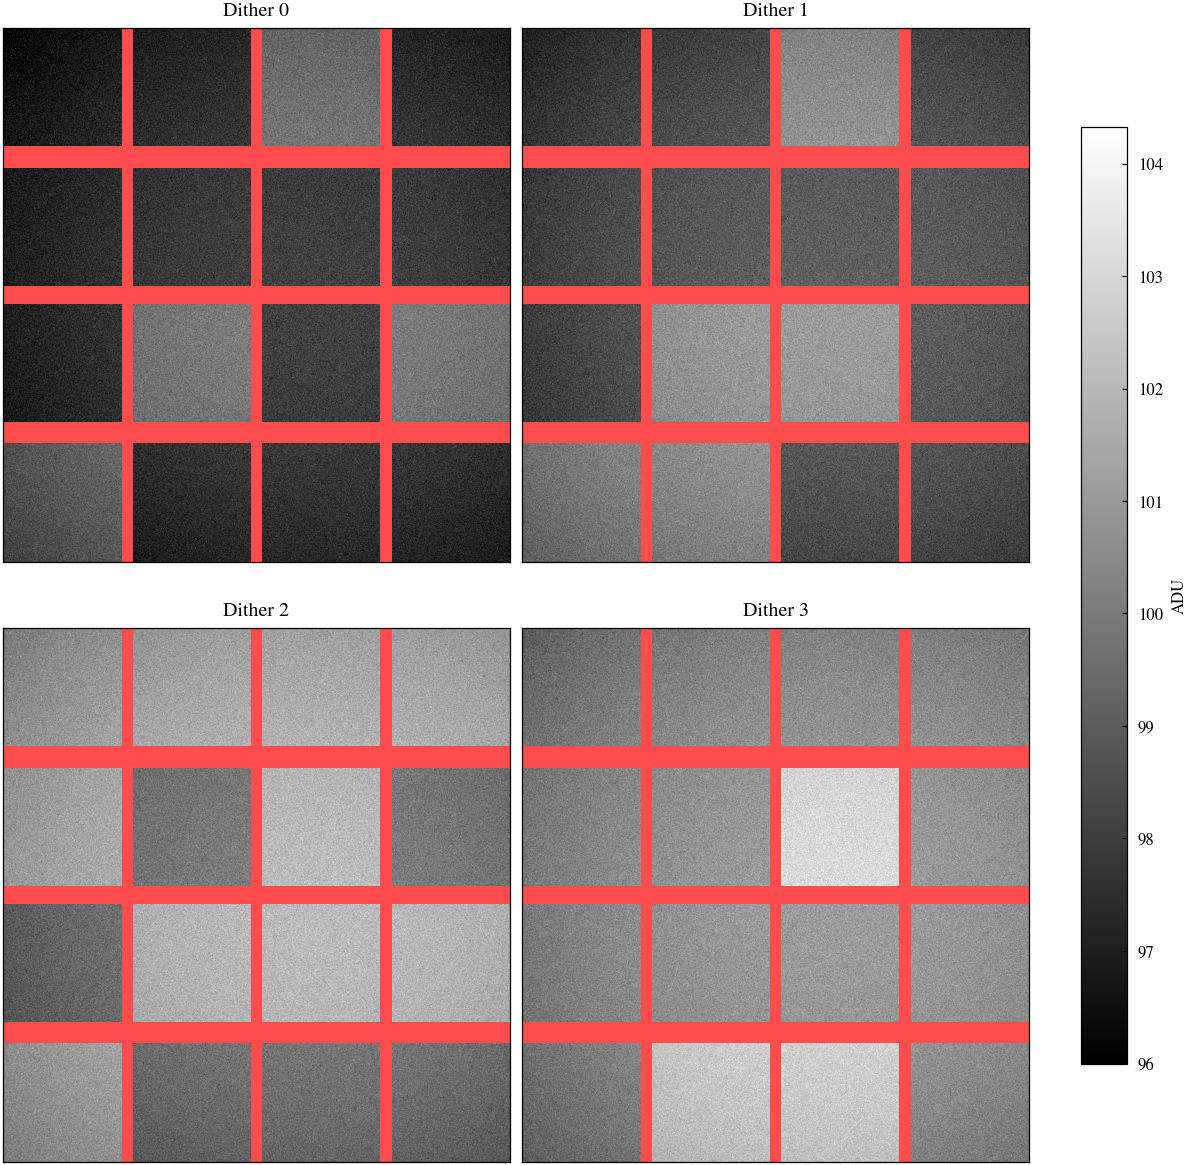

In [ ]:
_, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)
data = np.array(list(fpas.values()))
norm = ImageNormalize(data, interval=ZScaleInterval())
cmap = plt.get_cmap("gray")
cmap.set_bad("red", alpha=0.7)
for ax, dither_id, img in zip(axes.flat, fpas.keys(), fpas.values()):
    ax.set_aspect("equal")
    ax.imshow(img, cmap=cmap, norm=norm, origin="lower", interpolation=None)
    ax.set_title(f"Dither {dither_id}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.colorbar(
    axes[0, 0].images[0], ax=axes, orientation="vertical", label="ADU", shrink=0.8
);

## measure offsets

In [ ]:
res = measure_offset_per_observation(
    mock_dithers_dir,
    "2683",
    NISP,
    "H",
)

for dither pair ('0', '1')
number of chip pairs: 40
for dither pair ('0', '2')
number of chip pairs: 36
for dither pair ('0', '3')
number of chip pairs: 49
for dither pair ('1', '2')
number of chip pairs: 28
for dither pair ('1', '3')
number of chip pairs: 36
for dither pair ('2', '3')
number of chip pairs: 39


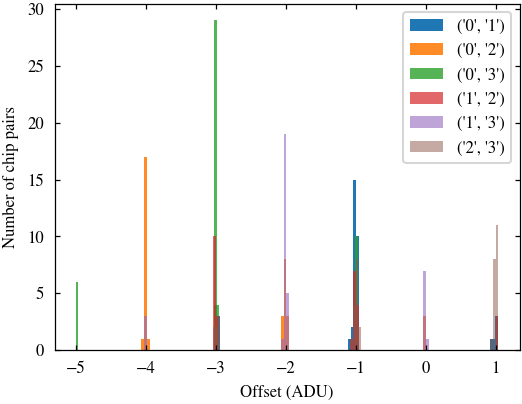

In [ ]:
alpha = 1
for r in res:
    print("for dither pair", r["dither pair"])
    print("number of chip pairs:", len(r["chip pair"]))
    offsets = np.array(r["offset"])
    # sort the offsets in the first column and its errors in the second column
    # offsets = np.array(sorted(offsets, key=lambda x: x[0]))
    # print(offsets[:, 0])
    # print(offsets[:, 1])
    plt.hist(offsets[:, 0], bins=100, label=f"{r['dither pair']}", alpha=alpha)
    alpha -= 0.1
plt.xlabel("Offset (ADU)")
plt.ylabel("Number of chip pairs")
plt.legend();

## correct for the offsets

In [ ]:
solutions, residual = solve_for_correction_per_observation(res)
print(solutions)
print(residual)

number of equations:  228
number of unknowns:  64
rank: 63, residuals: 0.2438010791470068
{'3.DET11': -0.8001145731959085, '3.DET12': -2.808275445276177, '3.DET13': -2.813213579928884, '3.DET14': -0.8145507727326831, '3.DET21': -0.8029468349548881, '3.DET22': -0.810301277910126, '3.DET23': -0.811806026159489, '3.DET24': -0.8208153183530724, '3.DET31': -0.797586593485972, '3.DET32': -0.8113247412993849, '3.DET33': -2.8377612603933486, '3.DET34': -0.8257288358054445, '3.DET41': -0.7926451371104848, '3.DET42': -0.8139972591337818, '3.DET43': -0.8217530196754791, '3.DET44': -0.8039347911503478, '1.DET11': -0.8065582875382513, '1.DET12': -0.803670568007044, '1.DET13': 1.1880519512325343, '1.DET14': 1.1795653858166806, '1.DET21': 1.2023408975565308, '1.DET22': -0.8067424292774096, '1.DET23': -0.8078140823774905, '1.DET24': 1.167083347289383, '1.DET31': 1.1984566708816964, '1.DET32': 1.1688297955908737, '1.DET33': 1.176854068376585, '1.DET34': 1.1915420441843103, '1.DET41': 1.2035516764779612

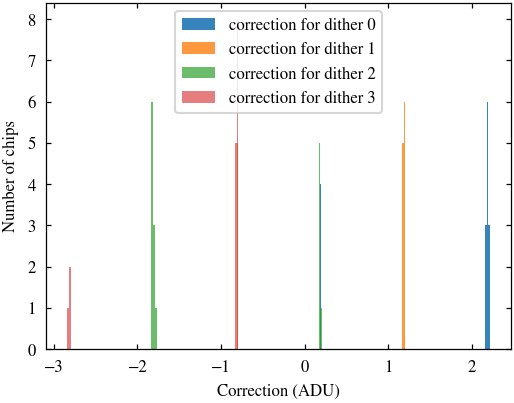

In [ ]:
solution0 = [value for key, value in solutions.items() if key.startswith("0")]
solution1 = [value for key, value in solutions.items() if key.startswith("1")]
solution2 = [value for key, value in solutions.items() if key.startswith("2")]
solution3 = [value for key, value in solutions.items() if key.startswith("3")]
plt.hist(solution0, bins=100, alpha=0.9, label="correction for dither 0")
plt.hist(solution1, bins=100, alpha=0.8, label="correction for dither 1")
plt.hist(solution2, bins=100, alpha=0.7, label="correction for dither 2")
plt.hist(solution3, bins=100, alpha=0.6, label="correction for dither 3")
plt.xlabel("Correction (ADU)")
plt.ylabel("Number of chips")
plt.legend();

In [ ]:
corr_mock_dithers_dir = default_data_path("Q1_R1_mock", "continuity", "sky_corr")
apply_correction(
    mock_dithers_dir,
    res[0]["obsid"],
    res[0]["instrument"],
    res[0]["filter"],
    solutions,
    out_dir=corr_mock_dithers_dir,
    overwrite=True,
)

In [ ]:
corr_mock_dithers = corr_mock_dithers_dir.glob("EUC_NIR_W-CAL-IMAGE_H-2683-*.fits")
corr_fpas = {}
for path in corr_mock_dithers:
    dither_id = get_dither_id_from_filename(path)
    with fits.open(path) as hdul:
        fpa = assemble_fpa_mosaic(hdul, instrument="NISP", binsize=10, unify_zpt=30)
        corr_fpas[dither_id] = fpa

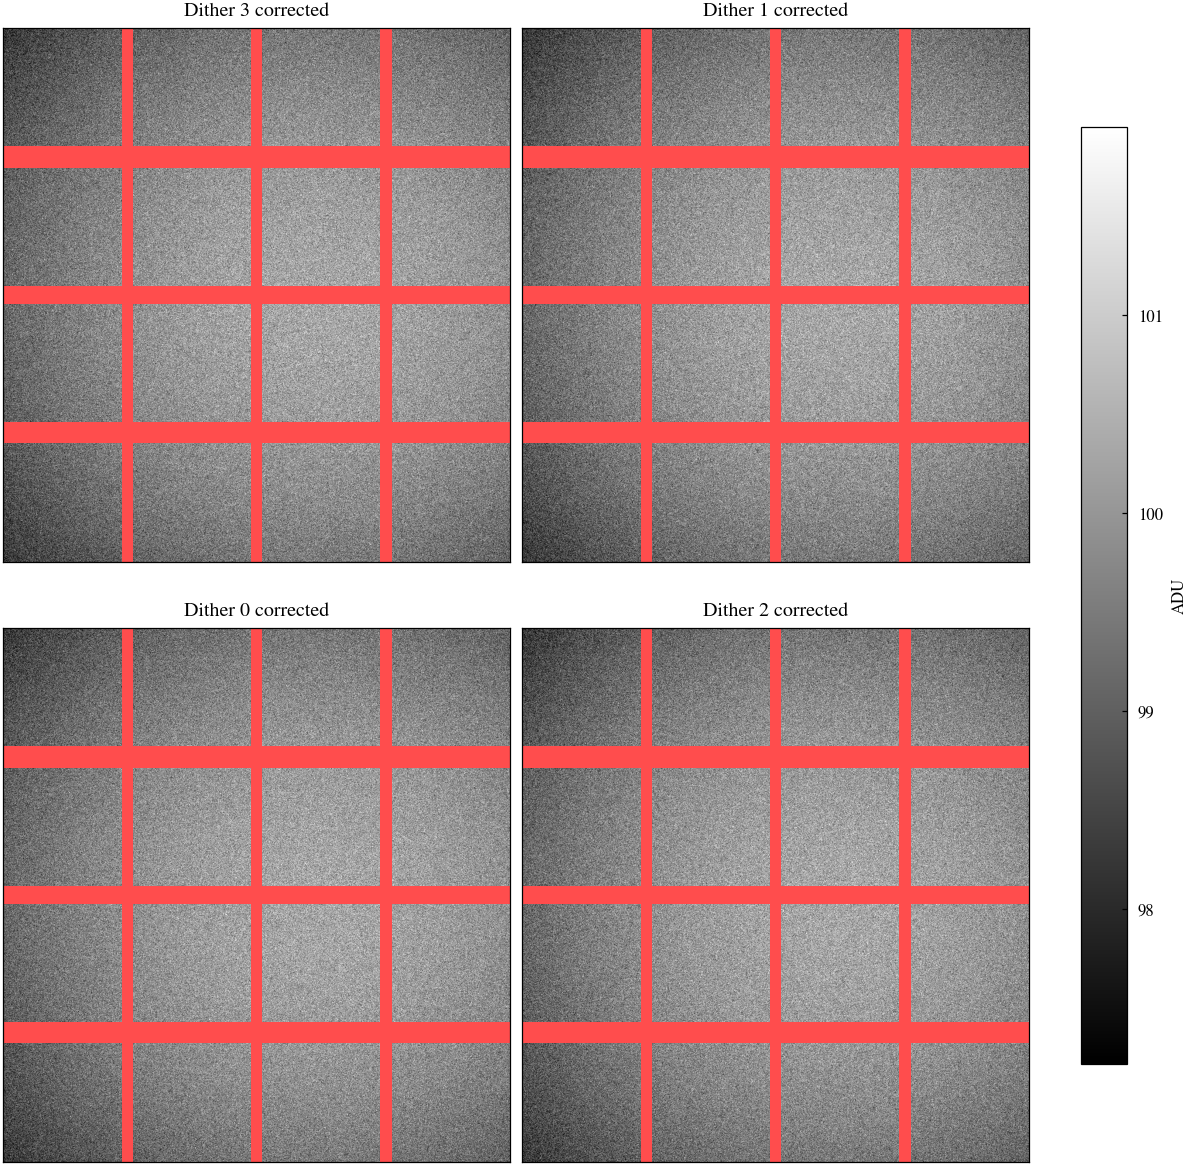

In [ ]:
_, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)
data = np.array(list(corr_fpas.values()))
norm = ImageNormalize(data, interval=ZScaleInterval())
cmap = plt.get_cmap("gray")
cmap.set_bad("red", alpha=0.7)
for ax, dither_id, img in zip(axes.flat, corr_fpas.keys(), corr_fpas.values()):
    ax.set_aspect("equal")
    ax.imshow(img, cmap=cmap, norm=norm, origin="lower", interpolation=None)
    ax.set_title(f"Dither {dither_id} corrected")
    ax.set_xticks([])
    ax.set_yticks([])
plt.colorbar(
    axes[0, 0].images[0], ax=axes, orientation="vertical", label="ADU", shrink=0.8
);

## measure the offset after correction

expect near zero offsets

In [ ]:
res_ = measure_offset_per_observation(
    corr_mock_dithers_dir,
    "2683",
    NISP,
    "H",
)

for dither pair ('0', '1')
number of chip pairs: 40
for dither pair ('0', '2')
number of chip pairs: 36
for dither pair ('0', '3')
number of chip pairs: 49
for dither pair ('1', '2')
number of chip pairs: 28
for dither pair ('1', '3')
number of chip pairs: 36
for dither pair ('2', '3')
number of chip pairs: 39
-0.0003411101738460606 0.016159394848030157


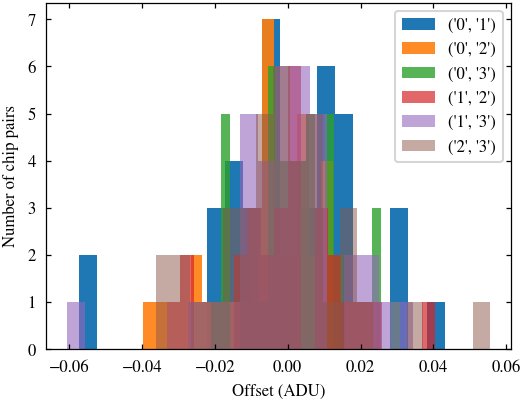

In [ ]:
alpha = 1
offset_arr = []
for r in res_:
    print("for dither pair", r["dither pair"])
    print("number of chip pairs:", len(r["chip pair"]))
    offsets = np.array(r["offset"])
    offset_arr.append(offsets[:, 0])
    # sort the offsets in the first column and its errors in the second column
    # offsets = np.array(sorted(offsets, key=lambda x: x[0]))
    # print(offsets[:, 0])
    # print(offsets[:, 1])
    plt.hist(offsets[:, 0], bins=20, label=f"{r['dither pair']}", alpha=alpha)
    alpha -= 0.1
plt.xlabel("Offset (ADU)")
plt.ylabel("Number of chip pairs")
plt.legend()

offset_arr = list(chain(*offset_arr))
offset_arr = np.array(offset_arr).ravel()
print(np.mean(offset_arr), np.std(offset_arr))

## Combine the dithers and compare the results

In [ ]:
from nicl.euclid.combine import combine

in_dir = mock_dithers_dir
out_dir = in_dir
combine(
    in_dir=in_dir,
    out_dir=out_dir,
    obs_ids=2683,
    filters=["H"],
    bkg_sub=False,
    pixel_scale=0.3,
    overwrite=True,
)

Initialized NISPCombiner(obsids=[2683], filters=['H'], cutout_cen=ALL, cutout_size=AUTO, pixel_scale=0.30 arcsec/pix, bkg_sub=False)
Found 4 H dithers for 1 obsids. Expected 4 dithers.


Preparing science and weight images took 0.1 mins.
Running SWarp: swarp @images.list -c config.swarp -PIXEL_SCALE 0.3
SWarp finished successfully. Elapsed time: 0.6 mins.
Postprocessing took 2.6 secs. Output saved to /home/ppzhg/euclid_data/Q1_R1_mock/continuity/sky/EUC_NIR_W-STK_H-2683.fits


In [ ]:
in_dir = corr_mock_dithers_dir
out_dir = in_dir
combine(
    in_dir=in_dir,
    out_dir=out_dir,
    obs_ids=2683,
    filters=["H"],
    bkg_sub=False,
    pixel_scale=0.3,
    overwrite=True,
)

Initialized NISPCombiner(obsids=[2683], filters=['H'], cutout_cen=ALL, cutout_size=AUTO, pixel_scale=0.30 arcsec/pix, bkg_sub=False)


Found 4 H dithers for 1 obsids. Expected 4 dithers.
Preparing science and weight images took 0.1 mins.
Running SWarp: swarp @images.list -c config.swarp -PIXEL_SCALE 0.3
SWarp finished successfully. Elapsed time: 0.5 mins.
Postprocessing took 2.7 secs. Output saved to /home/ppzhg/euclid_data/Q1_R1_mock/continuity/sky_corr/EUC_NIR_W-STK_H-2683.fits


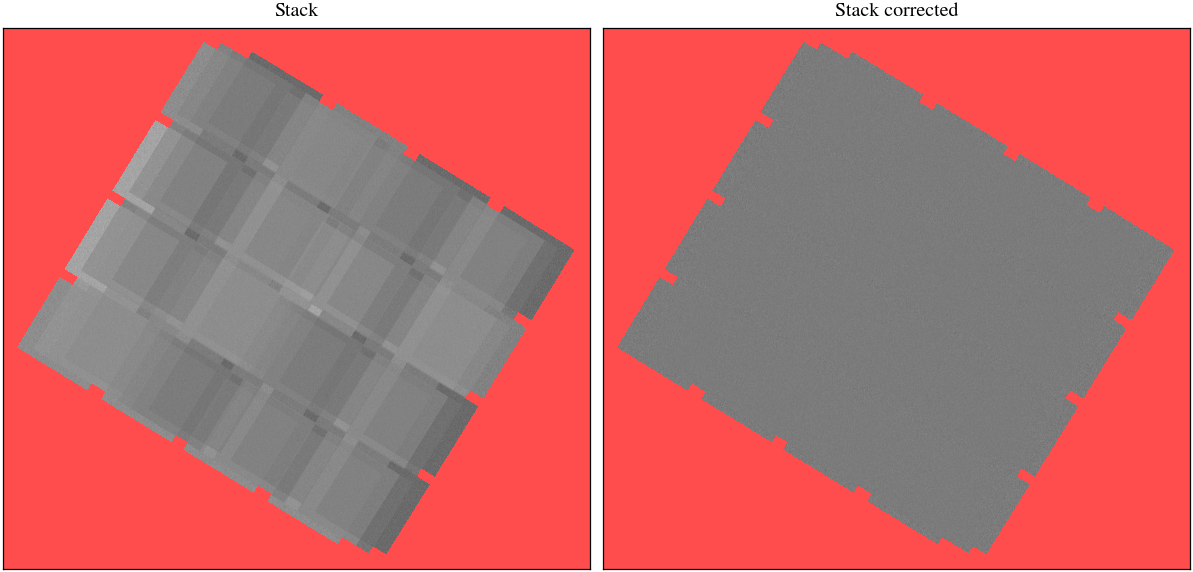

In [ ]:
stack = fits.getdata(mock_dithers_dir / "EUC_NIR_W-STK_H-2683.fits", 1)
stack_corr = fits.getdata(corr_mock_dithers_dir / "EUC_NIR_W-STK_H-2683.fits", 1)
_, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
norm = ImageNormalize(stack, interval=ZScaleInterval())
norm2 = ImageNormalize(stack_corr, interval=ZScaleInterval())
axes[0].imshow(stack, cmap=cmap, norm=norm, origin="lower", interpolation=None)
axes[0].set_title("Stack")
axes[1].imshow(stack_corr, cmap=cmap, norm=norm2, origin="lower", interpolation=None)
axes[1].set_title("Stack corrected")
# plt.colorbar(axes[0].images[0], ax=axes, orientation="vertical", label="ADU")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()